In [ ]:
!pip install torch_geometric

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import BorderlineSMOTE
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
datasets = {
    "60_40": {
        "train": "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/train_60_BorderlineSMOTE.csv",
        "test":  "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/test_40_BorderlineSMOTE.csv"
    },
    "70_30": {
        "train": "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/train_70_BorderlineSMOTE.csv",
        "test":  "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/test_30_BorderlineSMOTE.csv"
    },
    "80_20": {
        "train": "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/train_80_BorderlineSMOTE.csv",
        "test":  "/kaggle/input/datasets/saxenadivyansh/bitsecure/Borderline-20251209T171029Z-1-001/Borderline/test_20_BorderlineSMOTE.csv"
    },
}


In [2]:

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

In [3]:
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

In [4]:
# ---------------- DATASET CLASS ---------------- #

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
# ---------------- MODEL ---------------- #

class HybridModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.cnn_fc = nn.Linear(32, num_classes)

        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, num_classes)

        self.linear = nn.Linear(input_dim, hidden_dim)
        self.lin_fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        cnn_out = self.pool(self.conv1(x.unsqueeze(1))).squeeze(-1)
        cnn_prob = torch.softmax(self.cnn_fc(cnn_out), dim=1)

        lstm_out, _ = self.lstm(x.unsqueeze(1))
        lstm_prob = torch.softmax(self.lstm_fc(lstm_out[:, -1, :]), dim=1)

        lin_prob = torch.softmax(self.lin_fc(self.linear(x)), dim=1)

        return (cnn_prob + lstm_prob + lin_prob) / 3

In [6]:
# ---------------- TRAIN ---------------- #

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)

        log_outputs = torch.log(outputs + 1e-9)
        loss = criterion(log_outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total


In [7]:
# ---------------- EVAL ---------------- #

def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)

            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(outputs.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))

    acc = accuracy_score(true, preds)

    try:
        roc = roc_auc_score(true, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs


# Borderline SMOTE

In [8]:
import time
import psutil
import os

# ---------------- PIPELINE ---------------- #

def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    # ⏱️ Start time
    start_time = time.time()

    # 📊 Start RAM
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)  # MB

    X = df.drop("label", axis=1).values
    y = df["label"].values

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # 🔥 Borderline SMOTE ONLY on training
    smote = BorderlineSMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 📊 Distribution
    print("Train size:", len(y_train))
    print("Test size :", len(y_test))

    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", title="Train Distribution")
    plt.show()

    pd.Series(y_test).value_counts().sort_index().plot(kind="bar", title="Test Distribution")
    plt.show()

    # Loaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # Model
    model = HybridModel(X.shape[1], 64, len(np.unique(y))).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "acc": [], "val_acc": []}

    for epoch in range(epochs):
        loss, acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["acc"].append(acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={acc:.4f}, TestAcc={val_acc:.4f}, ROC={roc:.4f}")

    # Confusion Matrix
    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt="d")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.show()

    print(classification_report(true, preds))

    # ⏱️ End time
    end_time = time.time()
    total_time = end_time - start_time

    # 📊 End RAM
    end_ram = process.memory_info().rss / (1024 ** 2)  # MB
    ram_used = end_ram - start_ram

    # 📌 Print results
    print(f"\n⏱️ Runtime for {ratio_name}: {total_time:.2f} seconds")
    print(f"💾 RAM used for {ratio_name}: {ram_used:.2f} MB")


========== 60:40 ==========
Train size: 806032
Test size : 171050


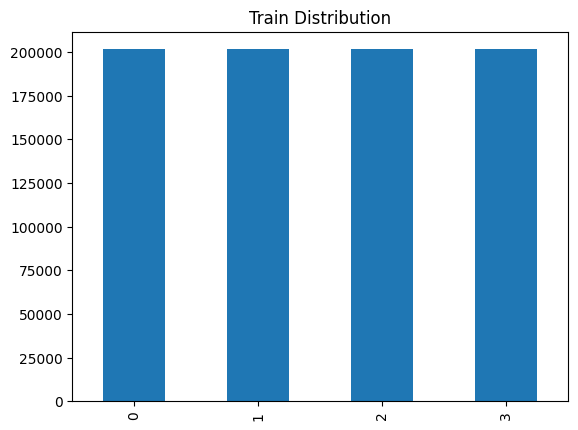

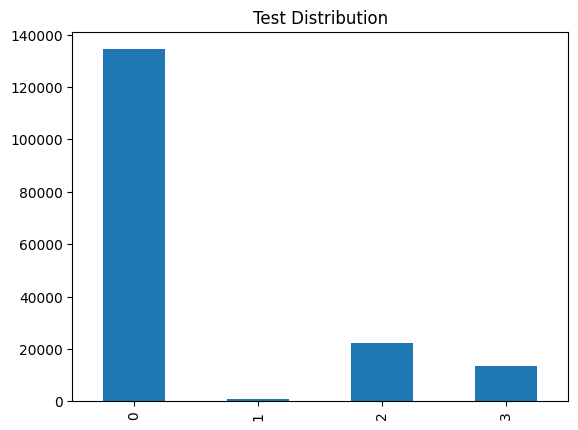

Epoch 1: Loss=0.4144, TrainAcc=0.9347, TestAcc=0.9238, ROC=0.9761
Epoch 2: Loss=0.3186, TrainAcc=0.9698, TestAcc=0.9245, ROC=0.9784
Epoch 3: Loss=0.3059, TrainAcc=0.9717, TestAcc=0.9245, ROC=0.9836
Epoch 4: Loss=0.2969, TrainAcc=0.9721, TestAcc=0.9245, ROC=0.9830
Epoch 5: Loss=0.2928, TrainAcc=0.9725, TestAcc=0.9246, ROC=0.9831
Epoch 6: Loss=0.2903, TrainAcc=0.9730, TestAcc=0.9251, ROC=0.9832
Epoch 7: Loss=0.2882, TrainAcc=0.9734, TestAcc=0.9248, ROC=0.9854
Epoch 8: Loss=0.2860, TrainAcc=0.9738, TestAcc=0.9254, ROC=0.9854
Epoch 9: Loss=0.2843, TrainAcc=0.9741, TestAcc=0.9252, ROC=0.9850
Epoch 10: Loss=0.2830, TrainAcc=0.9743, TestAcc=0.9253, ROC=0.9863
Epoch 11: Loss=0.2820, TrainAcc=0.9744, TestAcc=0.9261, ROC=0.9851
Epoch 12: Loss=0.2812, TrainAcc=0.9746, TestAcc=0.9257, ROC=0.9850
Epoch 13: Loss=0.2805, TrainAcc=0.9747, TestAcc=0.9261, ROC=0.9860
Epoch 14: Loss=0.2799, TrainAcc=0.9748, TestAcc=0.9272, ROC=0.9854
Epoch 15: Loss=0.2795, TrainAcc=0.9750, TestAcc=0.9266, ROC=0.9854
Epoc

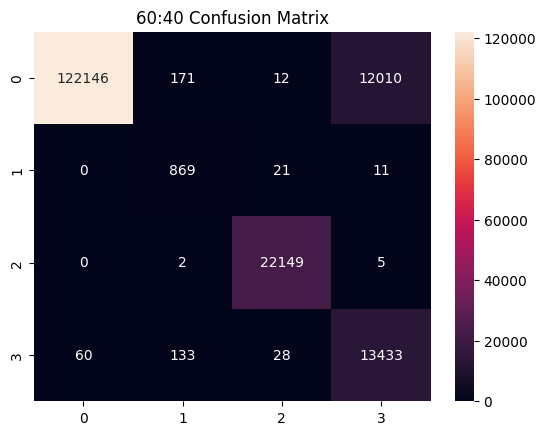

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    134339
           1       0.74      0.96      0.84       901
           2       1.00      1.00      1.00     22156
           3       0.53      0.98      0.69     13654

    accuracy                           0.93    171050
   macro avg       0.82      0.96      0.87    171050
weighted avg       0.96      0.93      0.94    171050


⏱️ Runtime for 60:40: 955.97 seconds
💾 RAM used for 60:40: 1077.99 MB

========== 70:30 ==========
Train size: 940368
Test size : 128288


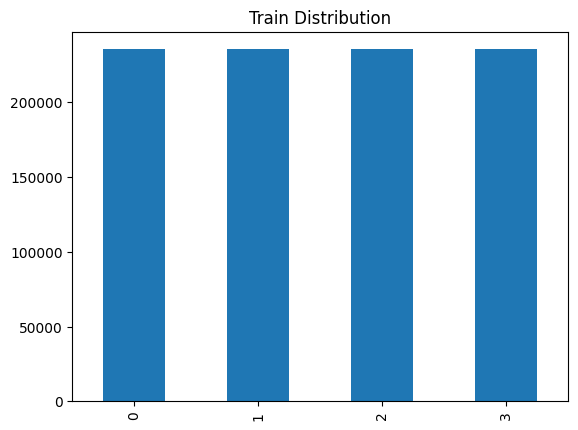

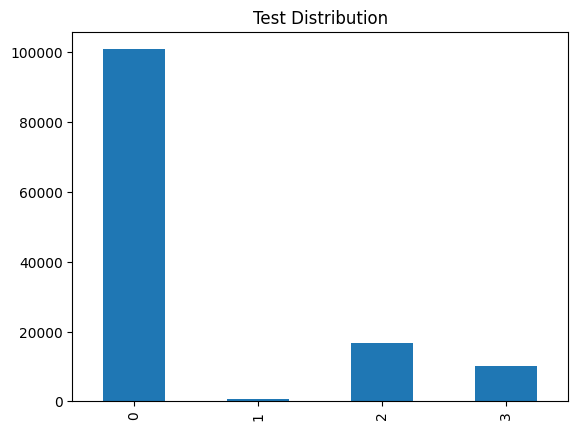

Epoch 1: Loss=0.3983, TrainAcc=0.9418, TestAcc=0.9250, ROC=0.9760
Epoch 2: Loss=0.3115, TrainAcc=0.9713, TestAcc=0.9267, ROC=0.9789
Epoch 3: Loss=0.3012, TrainAcc=0.9724, TestAcc=0.9249, ROC=0.9825
Epoch 4: Loss=0.2939, TrainAcc=0.9727, TestAcc=0.9249, ROC=0.9817
Epoch 5: Loss=0.2900, TrainAcc=0.9730, TestAcc=0.9250, ROC=0.9818
Epoch 6: Loss=0.2880, TrainAcc=0.9733, TestAcc=0.9256, ROC=0.9815
Epoch 7: Loss=0.2866, TrainAcc=0.9735, TestAcc=0.9256, ROC=0.9808
Epoch 8: Loss=0.2855, TrainAcc=0.9736, TestAcc=0.9254, ROC=0.9792
Epoch 9: Loss=0.2846, TrainAcc=0.9738, TestAcc=0.9258, ROC=0.9791
Epoch 10: Loss=0.2840, TrainAcc=0.9740, TestAcc=0.9261, ROC=0.9785
Epoch 11: Loss=0.2834, TrainAcc=0.9741, TestAcc=0.9258, ROC=0.9786
Epoch 12: Loss=0.2830, TrainAcc=0.9742, TestAcc=0.9267, ROC=0.9792
Epoch 13: Loss=0.2825, TrainAcc=0.9743, TestAcc=0.9257, ROC=0.9790
Epoch 14: Loss=0.2823, TrainAcc=0.9744, TestAcc=0.9257, ROC=0.9791
Epoch 15: Loss=0.2820, TrainAcc=0.9746, TestAcc=0.9254, ROC=0.9794
Epoc

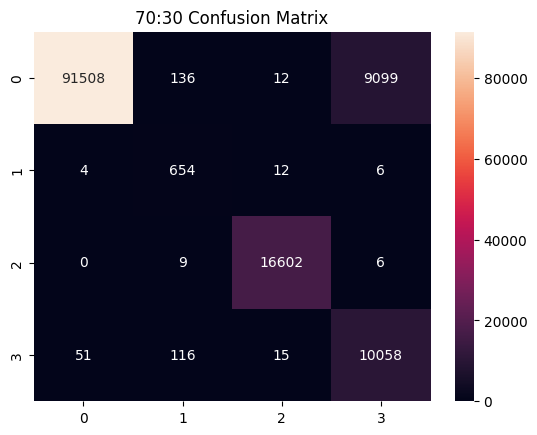

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    100755
           1       0.71      0.97      0.82       676
           2       1.00      1.00      1.00     16617
           3       0.52      0.98      0.68     10240

    accuracy                           0.93    128288
   macro avg       0.81      0.96      0.86    128288
weighted avg       0.96      0.93      0.94    128288


⏱️ Runtime for 70:30: 1086.29 seconds
💾 RAM used for 70:30: 417.09 MB

========== 80:20 ==========
Train size: 1074712
Test size : 85525


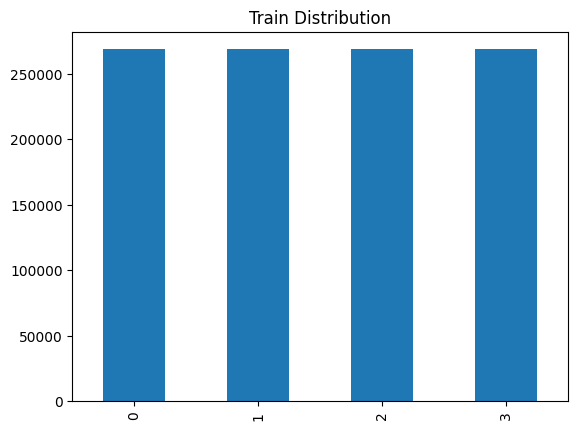

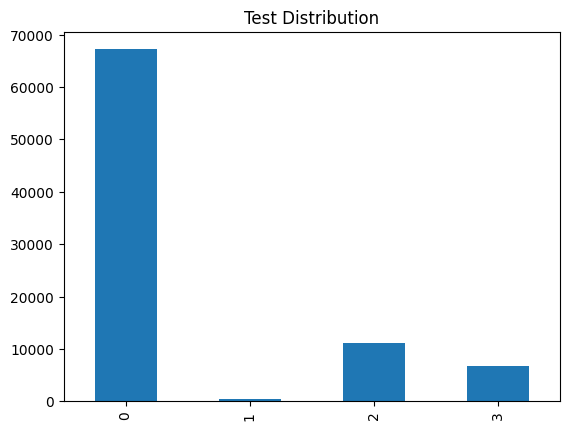

Epoch 1: Loss=0.3890, TrainAcc=0.9445, TestAcc=0.9260, ROC=0.9774
Epoch 2: Loss=0.3094, TrainAcc=0.9709, TestAcc=0.9264, ROC=0.9801
Epoch 3: Loss=0.2989, TrainAcc=0.9718, TestAcc=0.9250, ROC=0.9822
Epoch 4: Loss=0.2918, TrainAcc=0.9722, TestAcc=0.9245, ROC=0.9812
Epoch 5: Loss=0.2884, TrainAcc=0.9725, TestAcc=0.9250, ROC=0.9809
Epoch 6: Loss=0.2852, TrainAcc=0.9723, TestAcc=0.9250, ROC=0.9808
Epoch 7: Loss=0.2832, TrainAcc=0.9723, TestAcc=0.9252, ROC=0.9784
Epoch 8: Loss=0.2818, TrainAcc=0.9725, TestAcc=0.9258, ROC=0.9790
Epoch 9: Loss=0.2809, TrainAcc=0.9726, TestAcc=0.9257, ROC=0.9787
Epoch 10: Loss=0.2802, TrainAcc=0.9727, TestAcc=0.9258, ROC=0.9785
Epoch 11: Loss=0.2797, TrainAcc=0.9728, TestAcc=0.9262, ROC=0.9781
Epoch 12: Loss=0.2793, TrainAcc=0.9730, TestAcc=0.9260, ROC=0.9789
Epoch 13: Loss=0.2789, TrainAcc=0.9731, TestAcc=0.9262, ROC=0.9790
Epoch 14: Loss=0.2784, TrainAcc=0.9732, TestAcc=0.9265, ROC=0.9801
Epoch 15: Loss=0.2781, TrainAcc=0.9733, TestAcc=0.9256, ROC=0.9793
Epoc

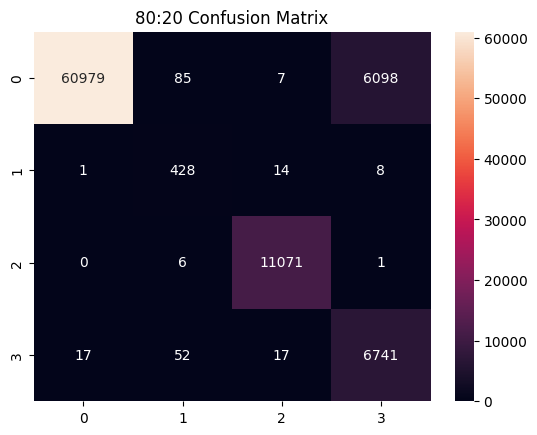

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     67169
           1       0.75      0.95      0.84       451
           2       1.00      1.00      1.00     11078
           3       0.52      0.99      0.69      6827

    accuracy                           0.93     85525
   macro avg       0.82      0.96      0.87     85525
weighted avg       0.96      0.93      0.94     85525


⏱️ Runtime for 80:20: 1215.98 seconds
💾 RAM used for 80:20: 456.50 MB


In [9]:
# ---------------- MAIN ---------------- #

df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", test_size=0.4)
run_split(df, "70:30", test_size=0.3)
run_split(df, "80:20", test_size=0.2)

# SMOTE

In [12]:
import time
import psutil
import os

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader


===== Split 60:40 with SMOTE =====
Original Training size: 256575 | Testing size: 171050
Training size after SMOTE: 806032


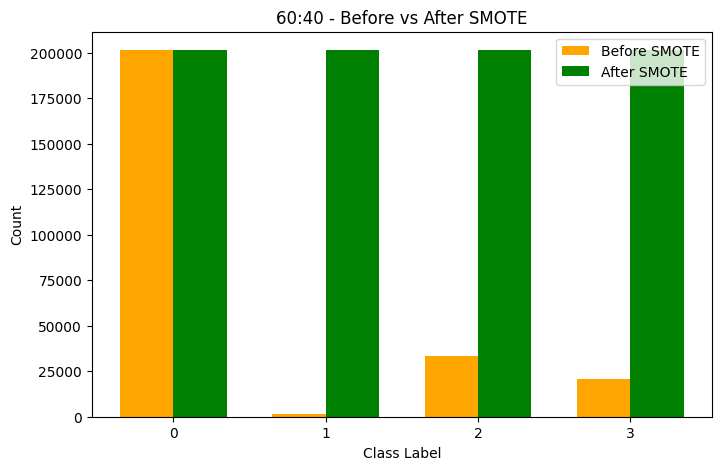

Epoch 1: TrainAcc=0.9456, TestAcc=0.9254, ROC=0.9790
Epoch 2: TrainAcc=0.9724, TestAcc=0.9263, ROC=0.9811
Epoch 3: TrainAcc=0.9736, TestAcc=0.9256, ROC=0.9832
Epoch 4: TrainAcc=0.9736, TestAcc=0.9253, ROC=0.9861
Epoch 5: TrainAcc=0.9742, TestAcc=0.9255, ROC=0.9865
Epoch 6: TrainAcc=0.9746, TestAcc=0.9246, ROC=0.9874
Epoch 7: TrainAcc=0.9750, TestAcc=0.9256, ROC=0.9877
Epoch 8: TrainAcc=0.9752, TestAcc=0.9253, ROC=0.9875
Epoch 9: TrainAcc=0.9752, TestAcc=0.9260, ROC=0.9876
Epoch 10: TrainAcc=0.9754, TestAcc=0.9256, ROC=0.9878
Epoch 11: TrainAcc=0.9755, TestAcc=0.9257, ROC=0.9879
Epoch 12: TrainAcc=0.9755, TestAcc=0.9258, ROC=0.9878
Epoch 13: TrainAcc=0.9756, TestAcc=0.9260, ROC=0.9882
Epoch 14: TrainAcc=0.9757, TestAcc=0.9257, ROC=0.9881
Epoch 15: TrainAcc=0.9756, TestAcc=0.9259, ROC=0.9879
Epoch 16: TrainAcc=0.9756, TestAcc=0.9259, ROC=0.9882
Epoch 17: TrainAcc=0.9757, TestAcc=0.9260, ROC=0.9878
Epoch 18: TrainAcc=0.9757, TestAcc=0.9257, ROC=0.9880
Epoch 19: TrainAcc=0.9757, TestAcc=0.

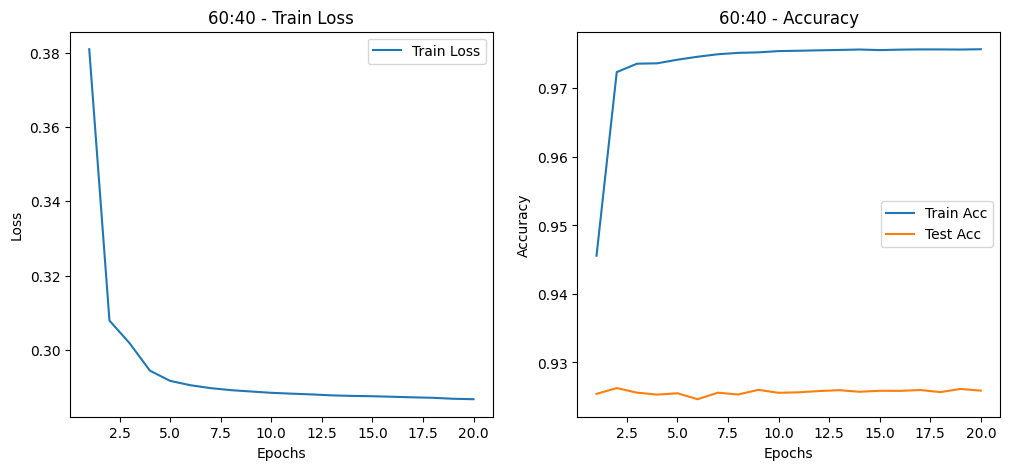

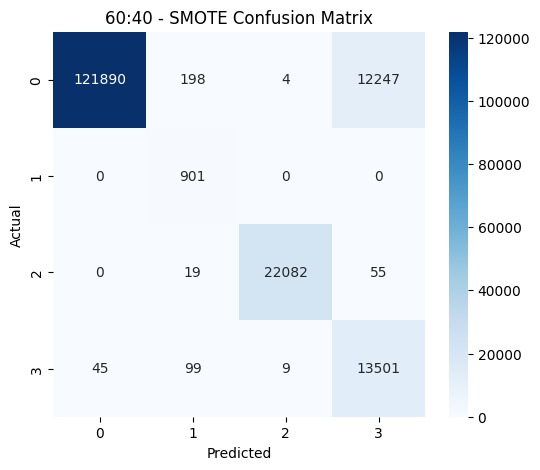

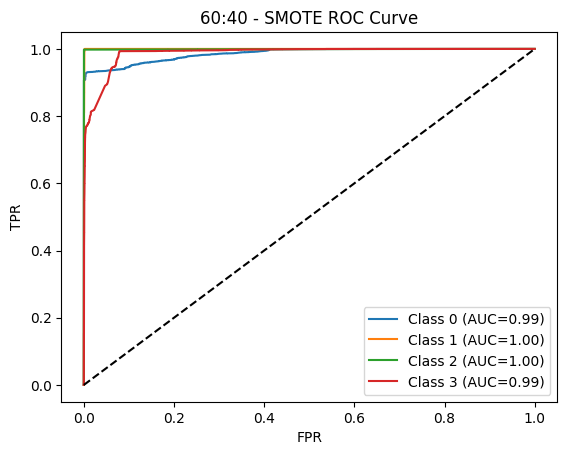

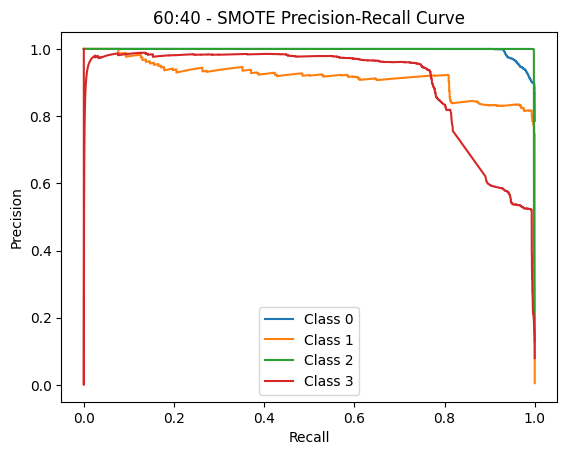

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    134339
           1       0.74      1.00      0.85       901
           2       1.00      1.00      1.00     22156
           3       0.52      0.99      0.68     13654

    accuracy                           0.93    171050
   macro avg       0.82      0.97      0.87    171050
weighted avg       0.96      0.93      0.94    171050

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 60:40: 906.53 seconds
💾 RAM used for 60:40: 136.66 MB

===== Split 70:30 with SMOTE =====
Original Training size: 299337 | Testing size: 128288
Training size after SMOTE: 940368


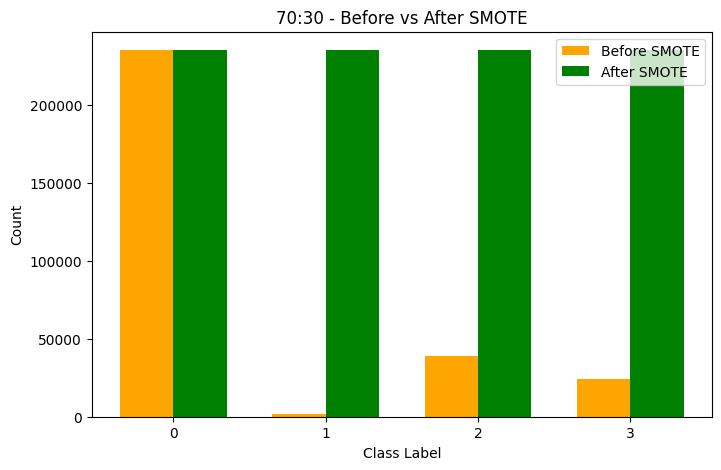

Epoch 1: TrainAcc=0.9481, TestAcc=0.9257, ROC=0.9804
Epoch 2: TrainAcc=0.9726, TestAcc=0.9275, ROC=0.9828
Epoch 3: TrainAcc=0.9736, TestAcc=0.9268, ROC=0.9837
Epoch 4: TrainAcc=0.9736, TestAcc=0.9251, ROC=0.9871
Epoch 5: TrainAcc=0.9740, TestAcc=0.9252, ROC=0.9883
Epoch 6: TrainAcc=0.9744, TestAcc=0.9255, ROC=0.9889
Epoch 7: TrainAcc=0.9748, TestAcc=0.9260, ROC=0.9893
Epoch 8: TrainAcc=0.9751, TestAcc=0.9262, ROC=0.9894
Epoch 9: TrainAcc=0.9753, TestAcc=0.9256, ROC=0.9892
Epoch 10: TrainAcc=0.9755, TestAcc=0.9266, ROC=0.9893
Epoch 11: TrainAcc=0.9759, TestAcc=0.9277, ROC=0.9894
Epoch 12: TrainAcc=0.9762, TestAcc=0.9294, ROC=0.9898
Epoch 13: TrainAcc=0.9764, TestAcc=0.9294, ROC=0.9901
Epoch 14: TrainAcc=0.9766, TestAcc=0.9299, ROC=0.9901
Epoch 15: TrainAcc=0.9768, TestAcc=0.9305, ROC=0.9904
Epoch 16: TrainAcc=0.9769, TestAcc=0.9298, ROC=0.9903
Epoch 17: TrainAcc=0.9770, TestAcc=0.9298, ROC=0.9903
Epoch 18: TrainAcc=0.9770, TestAcc=0.9302, ROC=0.9904
Epoch 19: TrainAcc=0.9771, TestAcc=0.

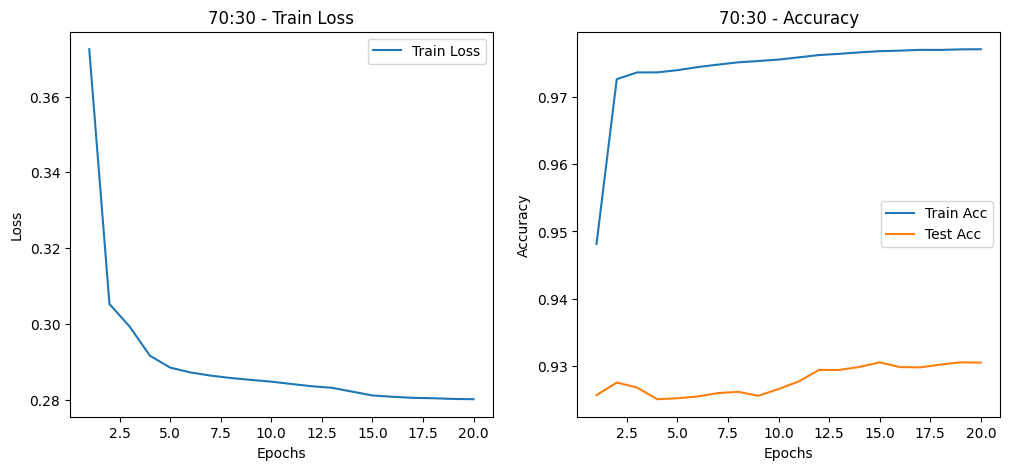

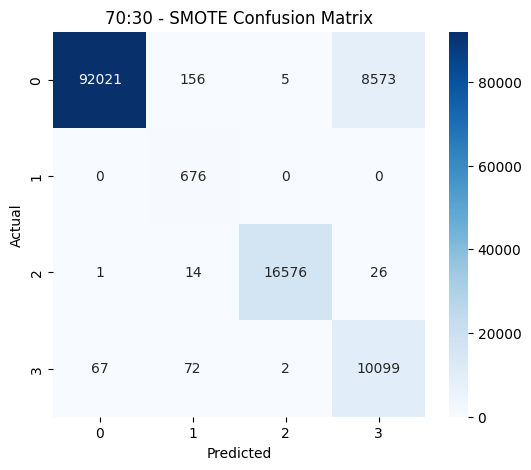

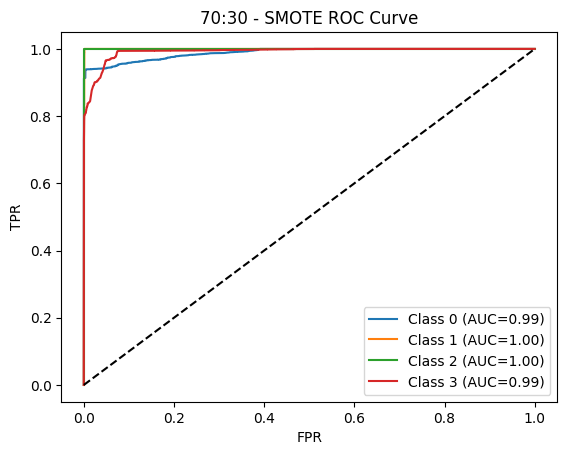

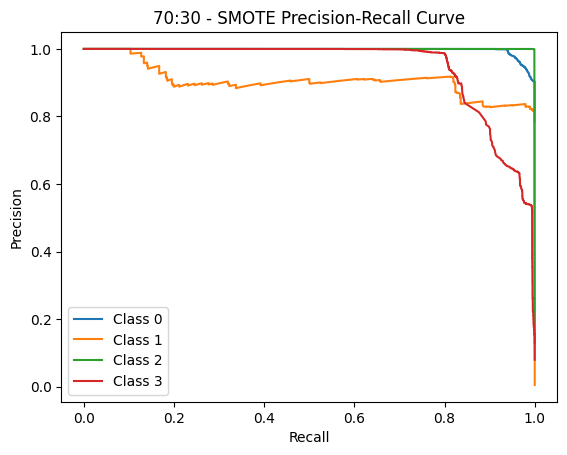

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    100755
           1       0.74      1.00      0.85       676
           2       1.00      1.00      1.00     16617
           3       0.54      0.99      0.70     10240

    accuracy                           0.93    128288
   macro avg       0.82      0.97      0.87    128288
weighted avg       0.96      0.93      0.94    128288

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 70:30: 1030.32 seconds
💾 RAM used for 70:30: 36.90 MB

===== Split 80:20 with SMOTE =====
Original Training size: 342100 | Testing size: 85525
Training size after SMOTE: 1074712


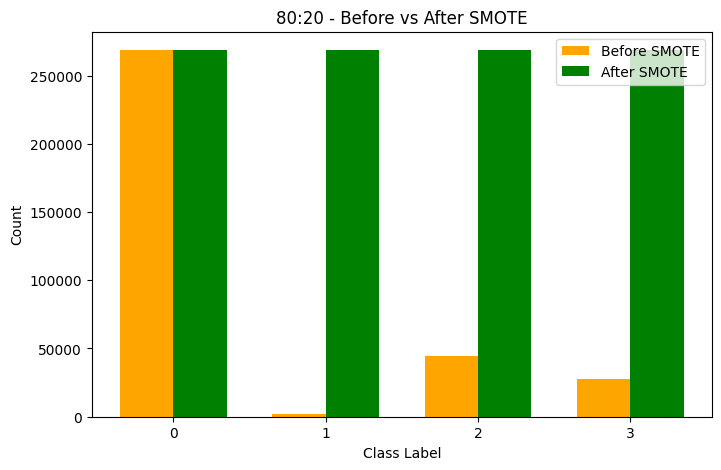

Epoch 1: TrainAcc=0.9473, TestAcc=0.9319, ROC=0.9953
Epoch 2: TrainAcc=0.9695, TestAcc=0.9330, ROC=0.9955
Epoch 3: TrainAcc=0.9709, TestAcc=0.9327, ROC=0.9953
Epoch 4: TrainAcc=0.9719, TestAcc=0.9361, ROC=0.9956
Epoch 5: TrainAcc=0.9726, TestAcc=0.9337, ROC=0.9953
Epoch 6: TrainAcc=0.9734, TestAcc=0.9321, ROC=0.9958
Epoch 7: TrainAcc=0.9740, TestAcc=0.9342, ROC=0.9960
Epoch 8: TrainAcc=0.9742, TestAcc=0.9359, ROC=0.9960
Epoch 9: TrainAcc=0.9744, TestAcc=0.9376, ROC=0.9959
Epoch 10: TrainAcc=0.9747, TestAcc=0.9371, ROC=0.9961
Epoch 11: TrainAcc=0.9748, TestAcc=0.9377, ROC=0.9962
Epoch 12: TrainAcc=0.9751, TestAcc=0.9345, ROC=0.9964
Epoch 13: TrainAcc=0.9752, TestAcc=0.9366, ROC=0.9966
Epoch 14: TrainAcc=0.9754, TestAcc=0.9337, ROC=0.9966
Epoch 15: TrainAcc=0.9764, TestAcc=0.9325, ROC=0.9968
Epoch 16: TrainAcc=0.9769, TestAcc=0.9343, ROC=0.9973
Epoch 17: TrainAcc=0.9769, TestAcc=0.9319, ROC=0.9974
Epoch 18: TrainAcc=0.9770, TestAcc=0.9327, ROC=0.9975
Epoch 19: TrainAcc=0.9770, TestAcc=0.

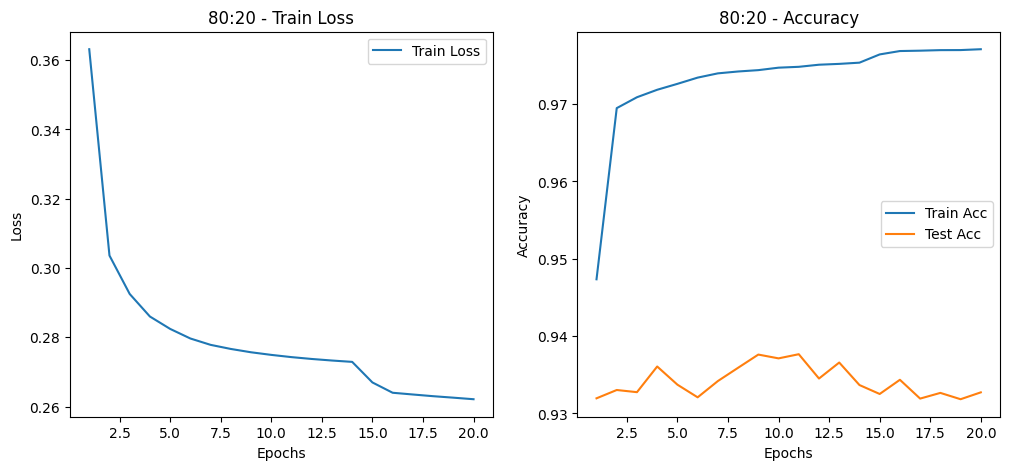

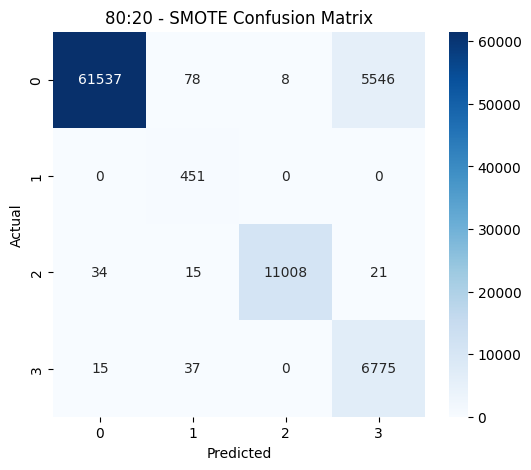

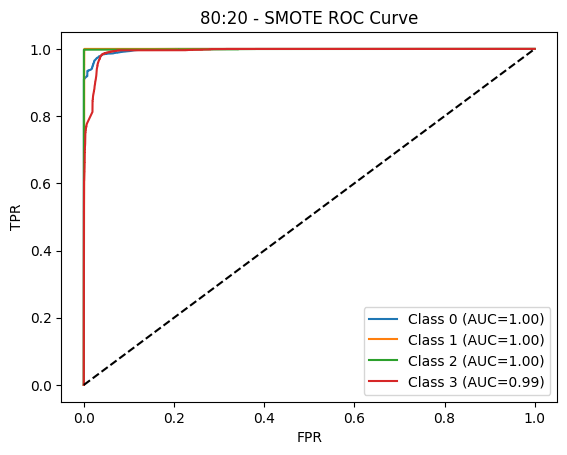

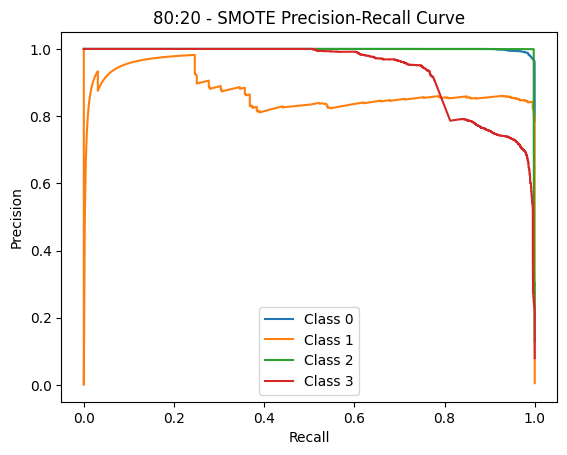

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     67169
           1       0.78      1.00      0.87       451
           2       1.00      0.99      1.00     11078
           3       0.55      0.99      0.71      6827

    accuracy                           0.93     85525
   macro avg       0.83      0.98      0.88     85525
weighted avg       0.96      0.93      0.94     85525

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 80:20: 1161.56 seconds
💾 RAM used for 80:20: 0.60 MB


In [13]:
splits = {"60:40":0.4, "70:30":0.3, "80:20":0.2}

for split_name, test_size in splits.items():

    print(f"\n===== Split {split_name} with SMOTE =====")

    # ⏱️ Start time
    start_time = time.time()

    # 💾 Start RAM
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)  # MB

    # Original dataset
    X = df.drop("label", axis=1).values
    y = df["label"].values

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print(f"Original Training size: {X_train.shape[0]} | Testing size: {X_test.shape[0]}")

    # 📊 BEFORE SMOTE
    unique_before, counts_before = np.unique(y_train, return_counts=True)

    # SMOTE
    smote = SMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print(f"Training size after SMOTE: {X_train.shape[0]}")

    # 📊 AFTER SMOTE
    unique_after, counts_after = np.unique(y_train, return_counts=True)

    # 📊 Combined comparison plot (best for reports)
    labels = np.unique(np.concatenate((unique_before, unique_after)))

    before_dict = dict(zip(unique_before, counts_before))
    after_dict = dict(zip(unique_after, counts_after))

    before_vals = [before_dict.get(i, 0) for i in labels]
    after_vals = [after_dict.get(i, 0) for i in labels]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, before_vals, width, label='Before SMOTE', color='orange')
    plt.bar(x + width/2, after_vals, width, label='After SMOTE', color='green')

    plt.xticks(x, labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title(f"{split_name} - Before vs After SMOTE")
    plt.legend()
    plt.show()

    # Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test_scaled, y_test), batch_size=64)

    # Model
    model = HybridModel(X.shape[1], 64, len(np.unique(y))).to(device)

    # Class weights
    class_weights = torch.tensor(
        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train),
        dtype=torch.float32
    ).to(device)

    criterion = torch.nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Training
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "roc_auc": []}

    for epoch in range(20):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc, preds, true, probs = evaluate(model, test_loader)

        history["train_loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["roc_auc"].append(roc)

        print(f"Epoch {epoch+1}: TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC={roc:.4f}")

    # 📉 Curves
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(range(1,21), history["train_loss"], label="Train Loss")
    plt.title(f"{split_name} - Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(1,21), history["train_acc"], label="Train Acc")
    plt.plot(range(1,21), history["val_acc"], label="Test Acc")
    plt.title(f"{split_name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

    # 🔥 Confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{split_name} - SMOTE Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 📈 ROC Curve
    num_classes = len(np.unique(y))
    true_bin = label_binarize(true, classes=list(range(num_classes)))

    plt.figure()
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(true_bin[:,i], probs[:,i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{split_name} - SMOTE ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

    # 📈 Precision-Recall Curve
    plt.figure()
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(true_bin[:,i], probs[:,i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.title(f"{split_name} - SMOTE Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # 📄 Classification report
    print(classification_report(true, preds))

    # ⏱️ End time
    end_time = time.time()
    total_time = end_time - start_time

    # 💾 End RAM
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    # 🚀 Optional GPU memory
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"🚀 GPU Memory used: {gpu_mem:.2f} MB")
        torch.cuda.reset_peak_memory_stats()

    # ✅ Final metrics
    print(f"\n⏱️ Runtime for {split_name}: {total_time:.2f} seconds")
    print(f"💾 RAM used for {split_name}: {ram_used:.2f} MB")

# ADASYN

In [14]:
import time
import psutil
import os

from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader


===== Split 60:40 with ADASYN =====
Original Training size: 256575 | Testing size: 171050
Training size after ADASYN: 805442


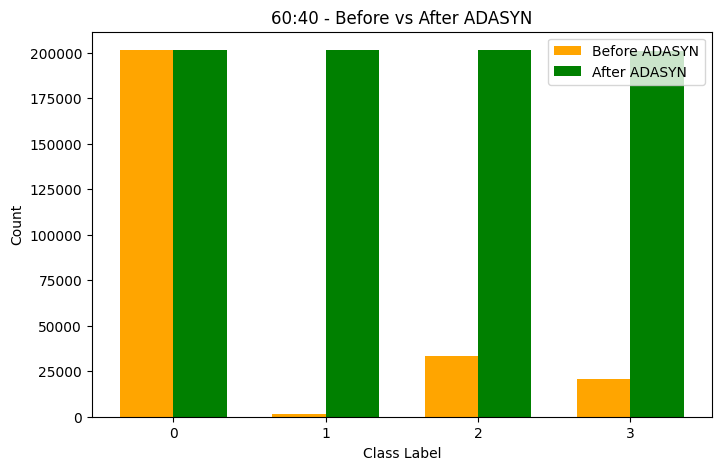

Epoch 1: TrainAcc=0.9176, TestAcc=0.9235, ROC=0.9961
Epoch 2: TrainAcc=0.9570, TestAcc=0.9236, ROC=0.9975
Epoch 3: TrainAcc=0.9629, TestAcc=0.9243, ROC=0.9976
Epoch 4: TrainAcc=0.9653, TestAcc=0.9241, ROC=0.9973
Epoch 5: TrainAcc=0.9680, TestAcc=0.9246, ROC=0.9973
Epoch 6: TrainAcc=0.9697, TestAcc=0.9261, ROC=0.9980
Epoch 7: TrainAcc=0.9706, TestAcc=0.9253, ROC=0.9978
Epoch 8: TrainAcc=0.9712, TestAcc=0.9253, ROC=0.9973
Epoch 9: TrainAcc=0.9715, TestAcc=0.9263, ROC=0.9977
Epoch 10: TrainAcc=0.9719, TestAcc=0.9261, ROC=0.9978
Epoch 11: TrainAcc=0.9722, TestAcc=0.9259, ROC=0.9978
Epoch 12: TrainAcc=0.9724, TestAcc=0.9264, ROC=0.9978
Epoch 13: TrainAcc=0.9727, TestAcc=0.9255, ROC=0.9978
Epoch 14: TrainAcc=0.9729, TestAcc=0.9267, ROC=0.9980
Epoch 15: TrainAcc=0.9731, TestAcc=0.9268, ROC=0.9978
Epoch 16: TrainAcc=0.9733, TestAcc=0.9260, ROC=0.9978
Epoch 17: TrainAcc=0.9736, TestAcc=0.9271, ROC=0.9978
Epoch 18: TrainAcc=0.9736, TestAcc=0.9255, ROC=0.9973
Epoch 19: TrainAcc=0.9737, TestAcc=0.

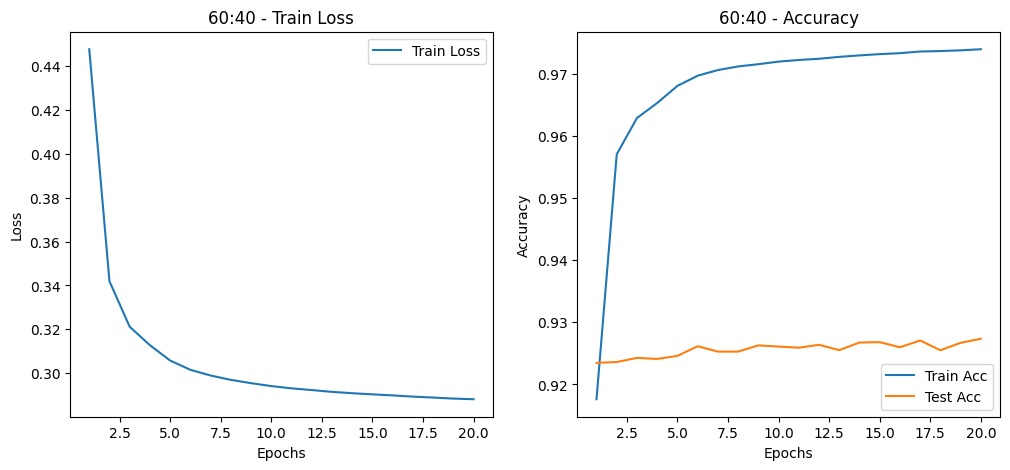

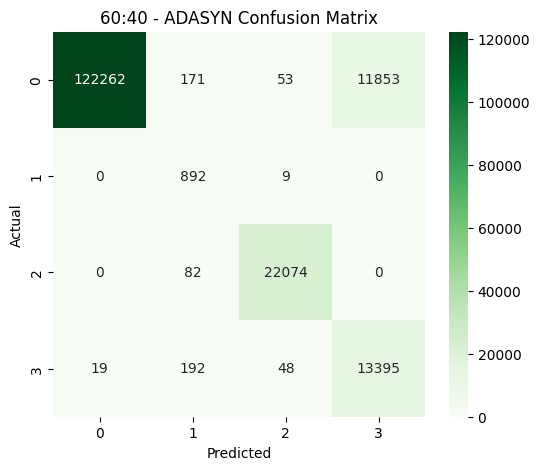

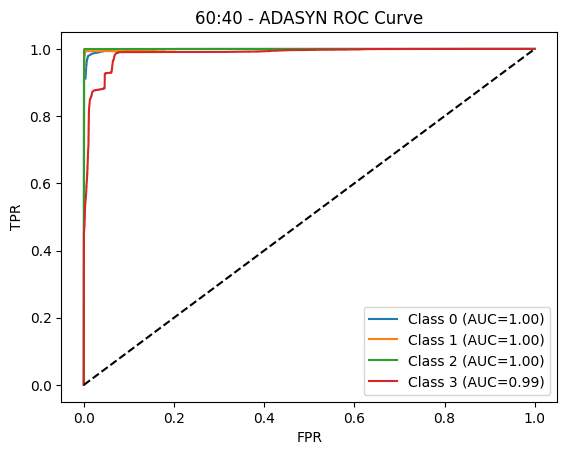

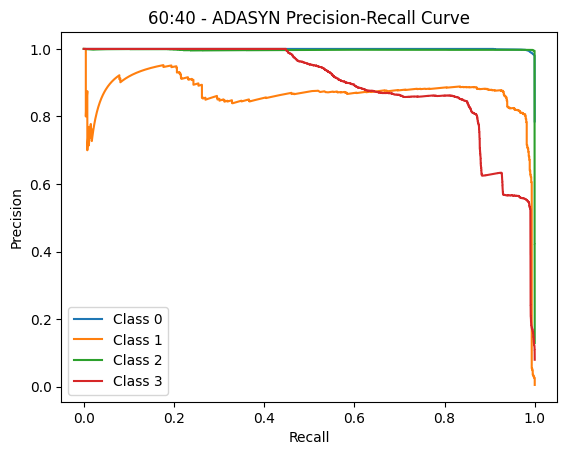

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    134339
           1       0.67      0.99      0.80       901
           2       1.00      1.00      1.00     22156
           3       0.53      0.98      0.69     13654

    accuracy                           0.93    171050
   macro avg       0.80      0.97      0.86    171050
weighted avg       0.96      0.93      0.94    171050

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 60:40: 949.30 seconds
💾 RAM used for 60:40: 10.81 MB

===== Split 70:30 with ADASYN =====
Original Training size: 299337 | Testing size: 128288
Training size after ADASYN: 942085


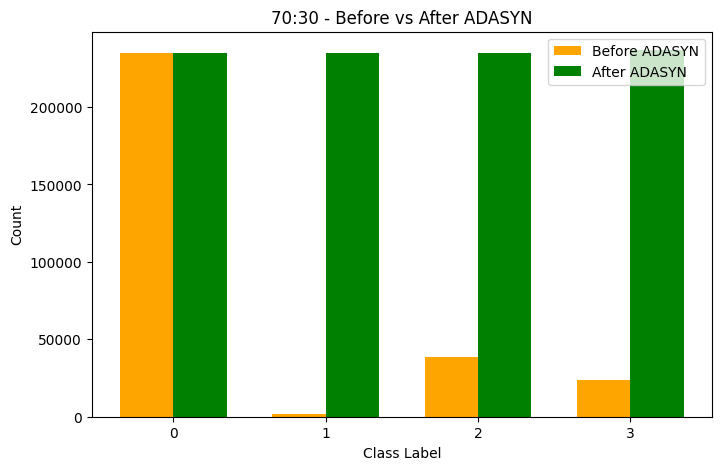

Epoch 1: TrainAcc=0.9205, TestAcc=0.9232, ROC=0.9906
Epoch 2: TrainAcc=0.9580, TestAcc=0.9234, ROC=0.9951
Epoch 3: TrainAcc=0.9641, TestAcc=0.9339, ROC=0.9964
Epoch 4: TrainAcc=0.9672, TestAcc=0.9240, ROC=0.9966
Epoch 5: TrainAcc=0.9687, TestAcc=0.9244, ROC=0.9971
Epoch 6: TrainAcc=0.9698, TestAcc=0.9251, ROC=0.9970
Epoch 7: TrainAcc=0.9703, TestAcc=0.9247, ROC=0.9969
Epoch 8: TrainAcc=0.9707, TestAcc=0.9280, ROC=0.9974
Epoch 9: TrainAcc=0.9711, TestAcc=0.9249, ROC=0.9975
Epoch 10: TrainAcc=0.9714, TestAcc=0.9251, ROC=0.9970
Epoch 11: TrainAcc=0.9717, TestAcc=0.9249, ROC=0.9976
Epoch 12: TrainAcc=0.9721, TestAcc=0.9252, ROC=0.9970
Epoch 13: TrainAcc=0.9722, TestAcc=0.9244, ROC=0.9971
Epoch 14: TrainAcc=0.9725, TestAcc=0.9242, ROC=0.9971
Epoch 15: TrainAcc=0.9727, TestAcc=0.9246, ROC=0.9976
Epoch 16: TrainAcc=0.9729, TestAcc=0.9254, ROC=0.9973
Epoch 17: TrainAcc=0.9730, TestAcc=0.9259, ROC=0.9977
Epoch 18: TrainAcc=0.9731, TestAcc=0.9256, ROC=0.9978
Epoch 19: TrainAcc=0.9733, TestAcc=0.

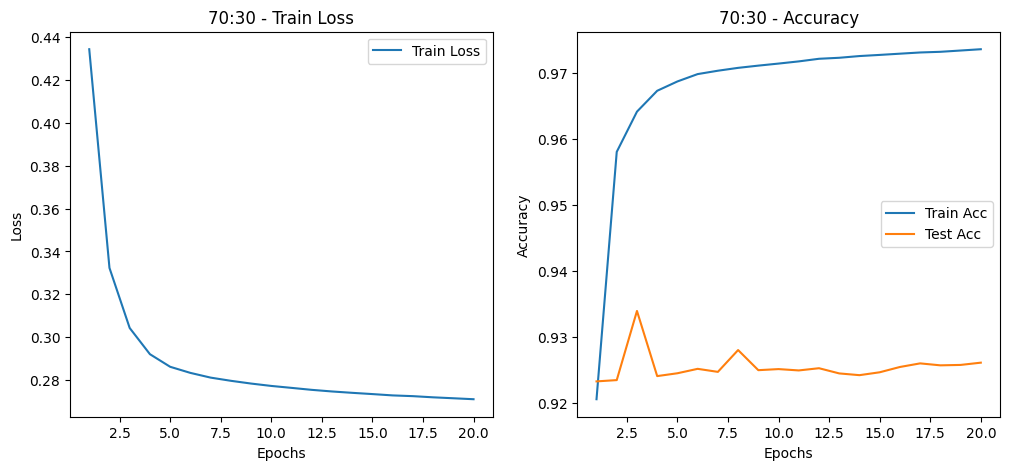

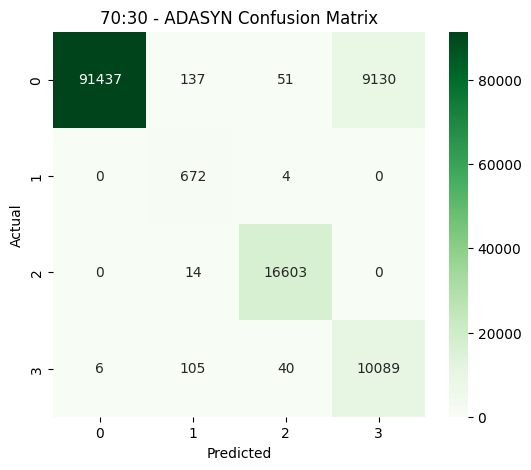

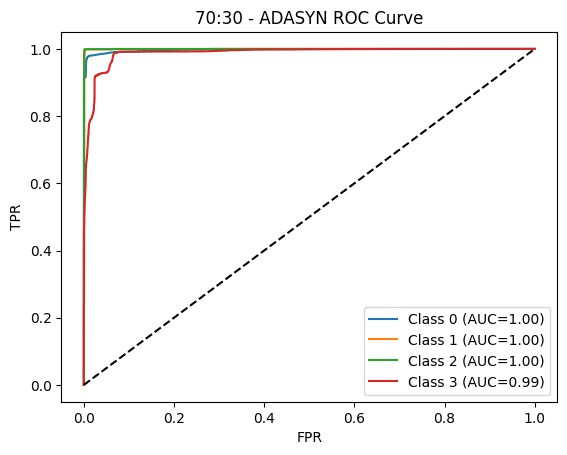

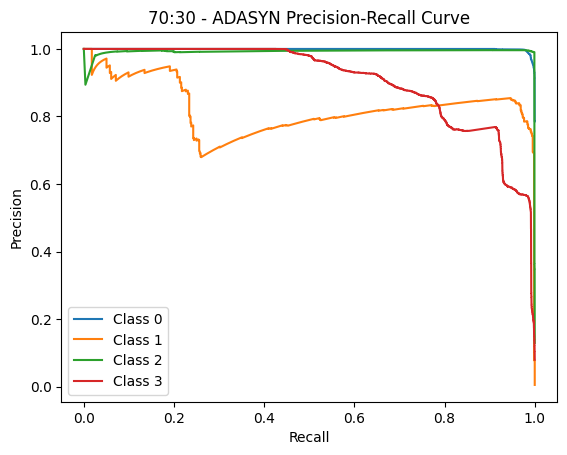

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    100755
           1       0.72      0.99      0.84       676
           2       0.99      1.00      1.00     16617
           3       0.52      0.99      0.68     10240

    accuracy                           0.93    128288
   macro avg       0.81      0.97      0.87    128288
weighted avg       0.96      0.93      0.94    128288

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 70:30: 1083.40 seconds
💾 RAM used for 70:30: 37.54 MB

===== Split 80:20 with ADASYN =====
Original Training size: 342100 | Testing size: 85525
Training size after ADASYN: 1076489


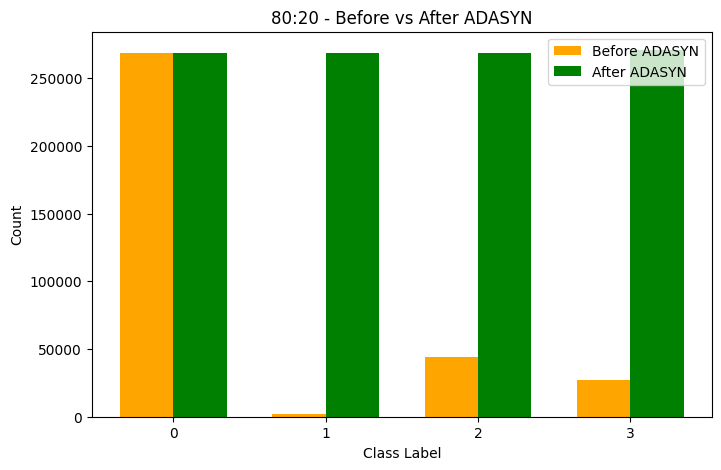

Epoch 1: TrainAcc=0.9233, TestAcc=0.9226, ROC=0.9937
Epoch 2: TrainAcc=0.9579, TestAcc=0.9222, ROC=0.9955
Epoch 3: TrainAcc=0.9608, TestAcc=0.9224, ROC=0.9949
Epoch 4: TrainAcc=0.9630, TestAcc=0.9234, ROC=0.9969
Epoch 5: TrainAcc=0.9668, TestAcc=0.9231, ROC=0.9965
Epoch 6: TrainAcc=0.9690, TestAcc=0.9250, ROC=0.9969
Epoch 7: TrainAcc=0.9697, TestAcc=0.9249, ROC=0.9972
Epoch 8: TrainAcc=0.9703, TestAcc=0.9238, ROC=0.9967
Epoch 9: TrainAcc=0.9713, TestAcc=0.9241, ROC=0.9974
Epoch 10: TrainAcc=0.9717, TestAcc=0.9240, ROC=0.9970
Epoch 11: TrainAcc=0.9721, TestAcc=0.9244, ROC=0.9968
Epoch 12: TrainAcc=0.9722, TestAcc=0.9251, ROC=0.9978
Epoch 13: TrainAcc=0.9724, TestAcc=0.9256, ROC=0.9973
Epoch 14: TrainAcc=0.9726, TestAcc=0.9248, ROC=0.9975
Epoch 15: TrainAcc=0.9726, TestAcc=0.9239, ROC=0.9972
Epoch 16: TrainAcc=0.9727, TestAcc=0.9244, ROC=0.9979
Epoch 17: TrainAcc=0.9729, TestAcc=0.9250, ROC=0.9971
Epoch 18: TrainAcc=0.9731, TestAcc=0.9255, ROC=0.9977
Epoch 19: TrainAcc=0.9730, TestAcc=0.

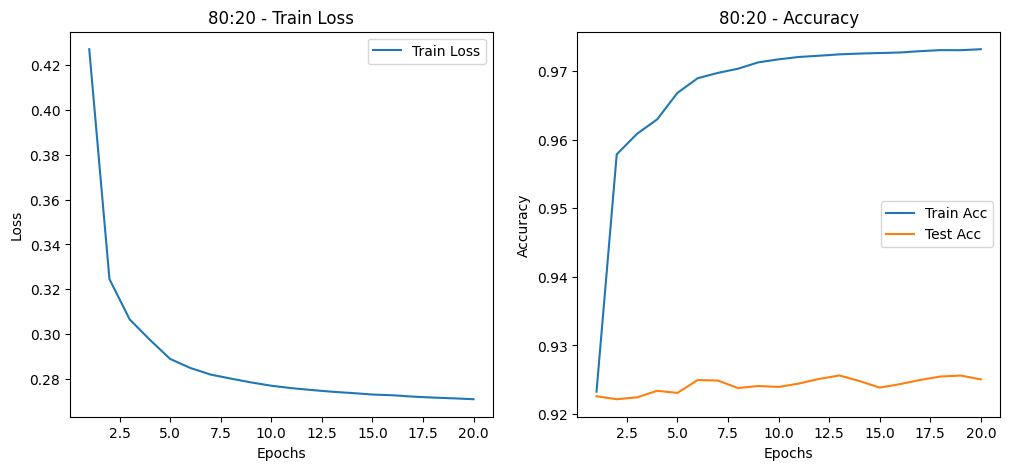

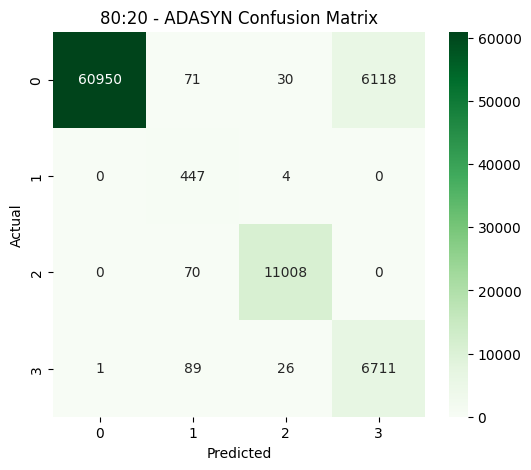

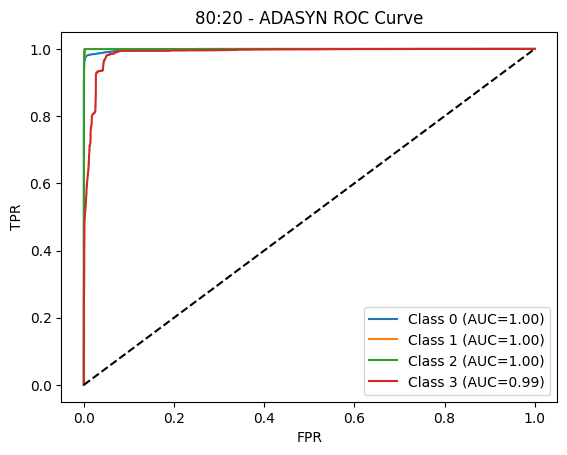

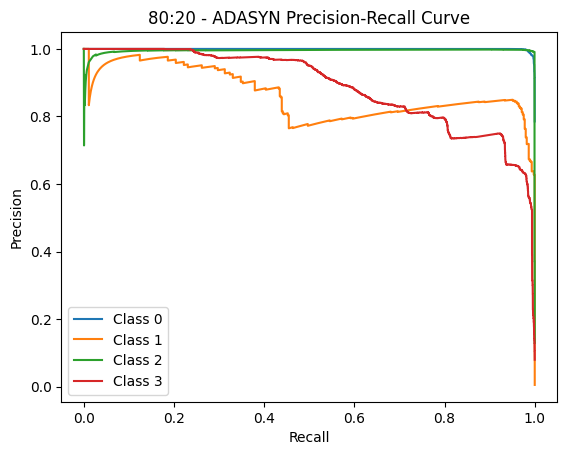

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     67169
           1       0.66      0.99      0.79       451
           2       0.99      0.99      0.99     11078
           3       0.52      0.98      0.68      6827

    accuracy                           0.93     85525
   macro avg       0.79      0.97      0.86     85525
weighted avg       0.96      0.93      0.93     85525

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 80:20: 1220.79 seconds
💾 RAM used for 80:20: 45.10 MB


In [15]:
splits = {"60:40":0.4, "70:30":0.3, "80:20":0.2}

for split_name, test_size in splits.items():

    print(f"\n===== Split {split_name} with ADASYN =====")

    # ⏱️ Start time
    start_time = time.time()

    # 💾 Start RAM
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)  # MB

    # Original dataset
    X = df.drop("label", axis=1).values
    y = df["label"].values

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print(f"Original Training size: {X_train.shape[0]} | Testing size: {X_test.shape[0]}")

    # 📊 BEFORE ADASYN
    unique_before, counts_before = np.unique(y_train, return_counts=True)

    # ADASYN
    adasyn = ADASYN()
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    print(f"Training size after ADASYN: {X_train.shape[0]}")

    # 📊 AFTER ADASYN
    unique_after, counts_after = np.unique(y_train, return_counts=True)

    # 📊 Combined comparison plot
    labels = np.unique(np.concatenate((unique_before, unique_after)))

    before_dict = dict(zip(unique_before, counts_before))
    after_dict = dict(zip(unique_after, counts_after))

    before_vals = [before_dict.get(i, 0) for i in labels]
    after_vals = [after_dict.get(i, 0) for i in labels]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, before_vals, width, label='Before ADASYN', color='orange')
    plt.bar(x + width/2, after_vals, width, label='After ADASYN', color='green')

    plt.xticks(x, labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title(f"{split_name} - Before vs After ADASYN")
    plt.legend()
    plt.show()

    # Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test_scaled, y_test), batch_size=64)

    # Model
    model = HybridModel(X.shape[1], 64, len(np.unique(y))).to(device)

    # Class weights
    class_weights = torch.tensor(
        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train),
        dtype=torch.float32
    ).to(device)

    criterion = torch.nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Training
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "roc_auc": []}

    for epoch in range(20):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc, preds, true, probs = evaluate(model, test_loader)

        history["train_loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["roc_auc"].append(roc)

        print(f"Epoch {epoch+1}: TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC={roc:.4f}")

    # 📉 Loss + Accuracy curves
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(range(1,21), history["train_loss"], label="Train Loss")
    plt.title(f"{split_name} - Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(1,21), history["train_acc"], label="Train Acc")
    plt.plot(range(1,21), history["val_acc"], label="Test Acc")
    plt.title(f"{split_name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

    # 🔥 Confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt="d", cmap="Greens")
    plt.title(f"{split_name} - ADASYN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 📈 ROC Curve
    num_classes = len(np.unique(y))
    true_bin = label_binarize(true, classes=list(range(num_classes)))

    plt.figure()
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(true_bin[:,i], probs[:,i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{split_name} - ADASYN ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

    # 📈 Precision-Recall Curve
    plt.figure()
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(true_bin[:,i], probs[:,i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.title(f"{split_name} - ADASYN Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # 📄 Classification report
    print(classification_report(true, preds))

    # ⏱️ End time
    end_time = time.time()
    total_time = end_time - start_time

    # 💾 End RAM
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    # 🚀 Optional GPU memory
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"🚀 GPU Memory used: {gpu_mem:.2f} MB")
        torch.cuda.reset_peak_memory_stats()

    # ✅ Final metrics
    print(f"\n⏱️ Runtime for {split_name}: {total_time:.2f} seconds")
    print(f"💾 RAM used for {split_name}: {ram_used:.2f} MB")

# ADASYN + TOMEK_Links


In [16]:
import time
import psutil
import os

from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader


===== Split 60:40 with ADASYN + TomekLinks =====
Original Training size: 256575 | Testing size: 171050
Training size after ADASYN + TomekLinks: 796561


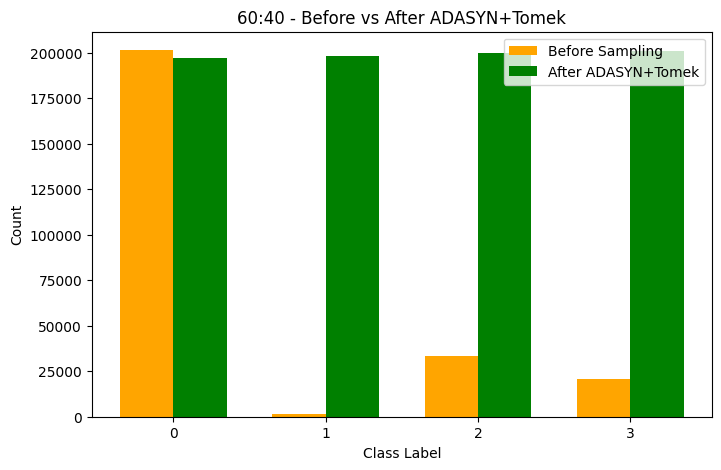

Epoch 1: TrainAcc=0.9173, TestAcc=0.9232, ROC=0.9835
Epoch 2: TrainAcc=0.9593, TestAcc=0.9234, ROC=0.9853
Epoch 3: TrainAcc=0.9643, TestAcc=0.9236, ROC=0.9874
Epoch 4: TrainAcc=0.9668, TestAcc=0.9244, ROC=0.9875
Epoch 5: TrainAcc=0.9676, TestAcc=0.9255, ROC=0.9879
Epoch 6: TrainAcc=0.9686, TestAcc=0.9265, ROC=0.9870
Epoch 7: TrainAcc=0.9694, TestAcc=0.9266, ROC=0.9872
Epoch 8: TrainAcc=0.9722, TestAcc=0.9465, ROC=0.9947
Epoch 9: TrainAcc=0.9814, TestAcc=0.9624, ROC=0.9963
Epoch 10: TrainAcc=0.9829, TestAcc=0.9642, ROC=0.9961
Epoch 11: TrainAcc=0.9836, TestAcc=0.9664, ROC=0.9967
Epoch 12: TrainAcc=0.9844, TestAcc=0.9664, ROC=0.9963
Epoch 13: TrainAcc=0.9851, TestAcc=0.9612, ROC=0.9958
Epoch 14: TrainAcc=0.9858, TestAcc=0.9697, ROC=0.9968
Epoch 15: TrainAcc=0.9863, TestAcc=0.9716, ROC=0.9968
Epoch 16: TrainAcc=0.9869, TestAcc=0.9716, ROC=0.9970
Epoch 17: TrainAcc=0.9874, TestAcc=0.9695, ROC=0.9967
Epoch 18: TrainAcc=0.9876, TestAcc=0.9719, ROC=0.9971
Epoch 19: TrainAcc=0.9877, TestAcc=0.

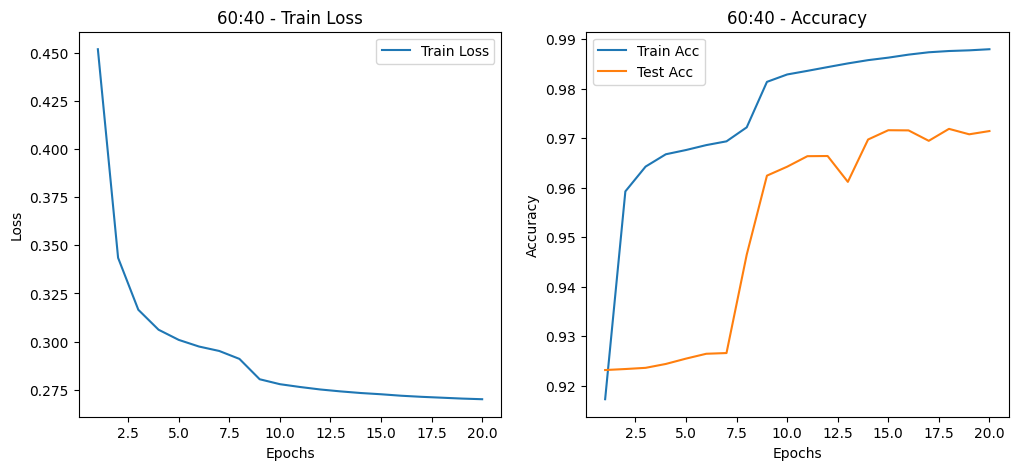

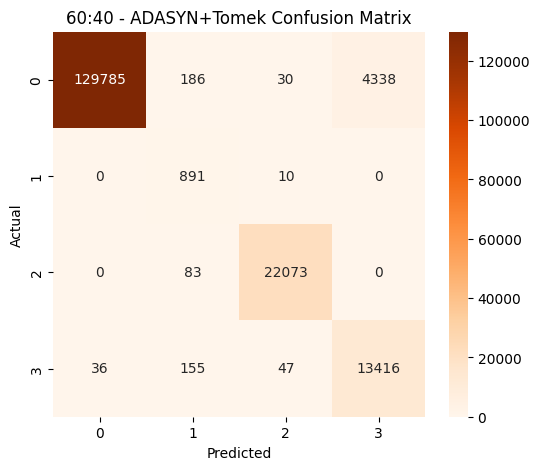

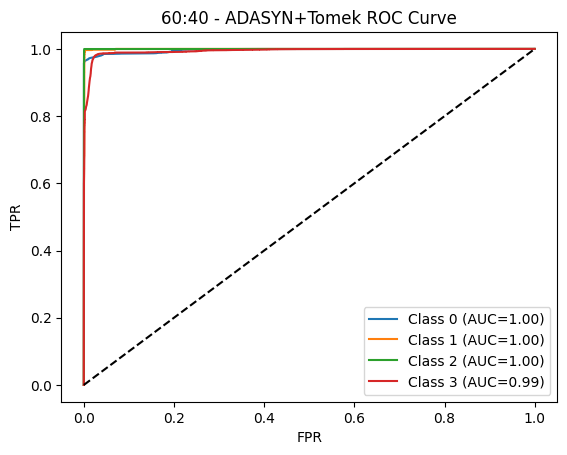

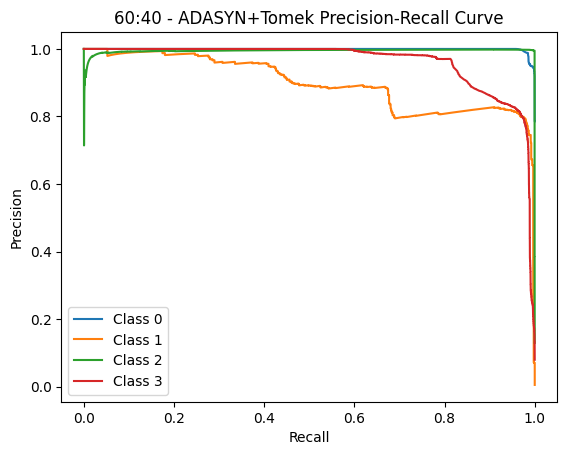

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    134339
           1       0.68      0.99      0.80       901
           2       1.00      1.00      1.00     22156
           3       0.76      0.98      0.85     13654

    accuracy                           0.97    171050
   macro avg       0.86      0.98      0.91    171050
weighted avg       0.98      0.97      0.97    171050

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 60:40: 2522.99 seconds
💾 RAM used for 60:40: -64.59 MB

===== Split 70:30 with ADASYN + TomekLinks =====
Original Training size: 299337 | Testing size: 128288
Training size after ADASYN + TomekLinks: 931327


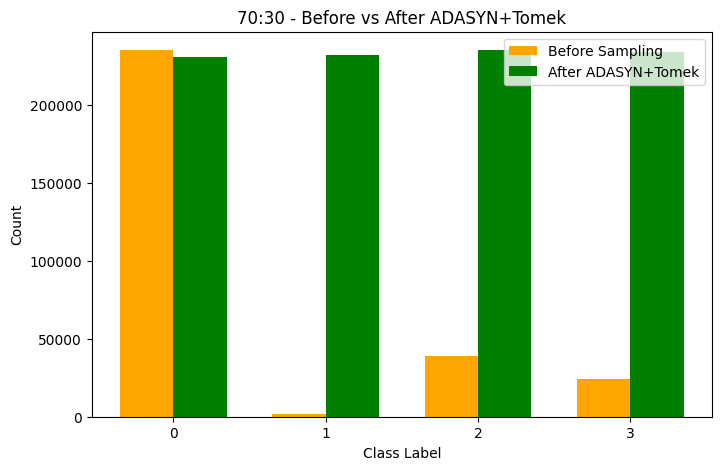

Epoch 1: TrainAcc=0.9222, TestAcc=0.9241, ROC=0.9820
Epoch 2: TrainAcc=0.9590, TestAcc=0.9236, ROC=0.9871
Epoch 3: TrainAcc=0.9652, TestAcc=0.9249, ROC=0.9871
Epoch 4: TrainAcc=0.9678, TestAcc=0.9260, ROC=0.9877
Epoch 5: TrainAcc=0.9714, TestAcc=0.9403, ROC=0.9899
Epoch 6: TrainAcc=0.9778, TestAcc=0.9598, ROC=0.9959
Epoch 7: TrainAcc=0.9826, TestAcc=0.9627, ROC=0.9963
Epoch 8: TrainAcc=0.9840, TestAcc=0.9654, ROC=0.9962
Epoch 9: TrainAcc=0.9849, TestAcc=0.9685, ROC=0.9968
Epoch 10: TrainAcc=0.9854, TestAcc=0.9722, ROC=0.9971
Epoch 11: TrainAcc=0.9857, TestAcc=0.9668, ROC=0.9965
Epoch 12: TrainAcc=0.9863, TestAcc=0.9708, ROC=0.9968
Epoch 13: TrainAcc=0.9867, TestAcc=0.9649, ROC=0.9965
Epoch 14: TrainAcc=0.9867, TestAcc=0.9719, ROC=0.9971
Epoch 15: TrainAcc=0.9870, TestAcc=0.9609, ROC=0.9957
Epoch 16: TrainAcc=0.9873, TestAcc=0.9672, ROC=0.9966
Epoch 17: TrainAcc=0.9875, TestAcc=0.9719, ROC=0.9968
Epoch 18: TrainAcc=0.9878, TestAcc=0.9682, ROC=0.9966
Epoch 19: TrainAcc=0.9879, TestAcc=0.

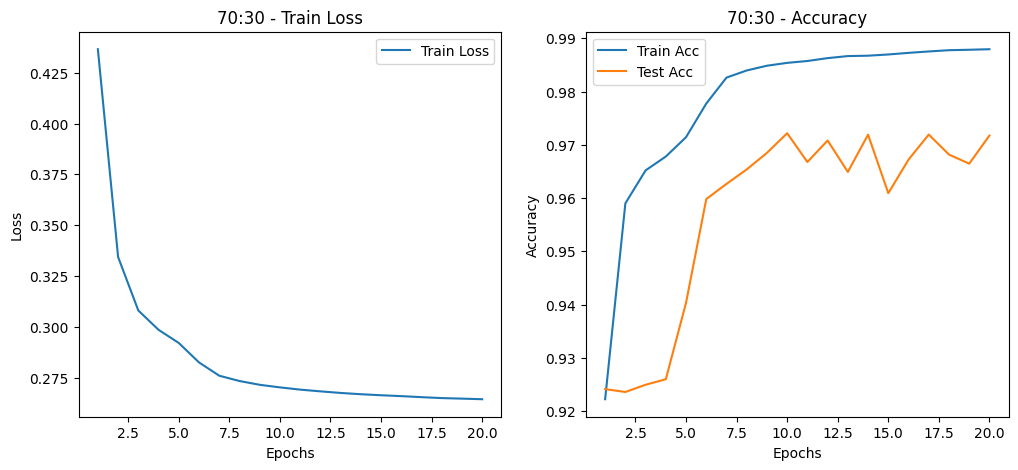

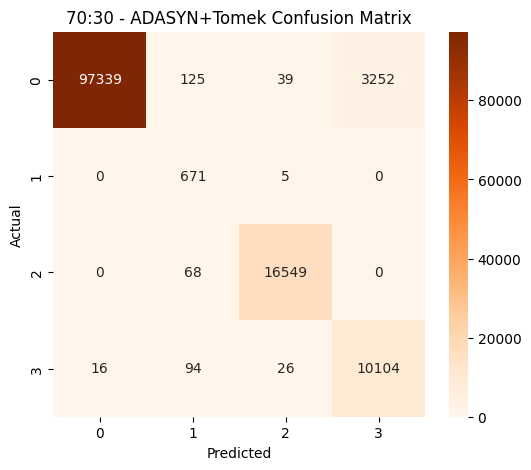

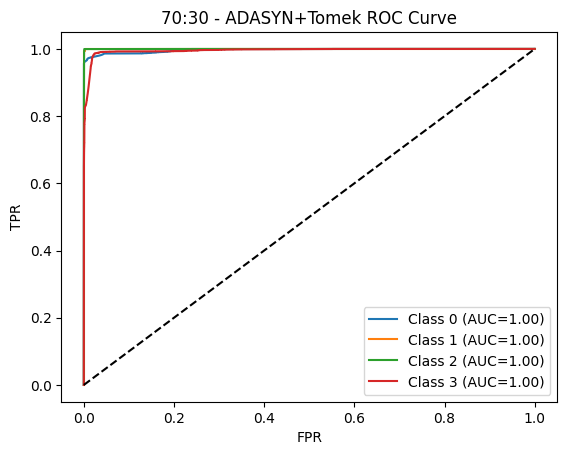

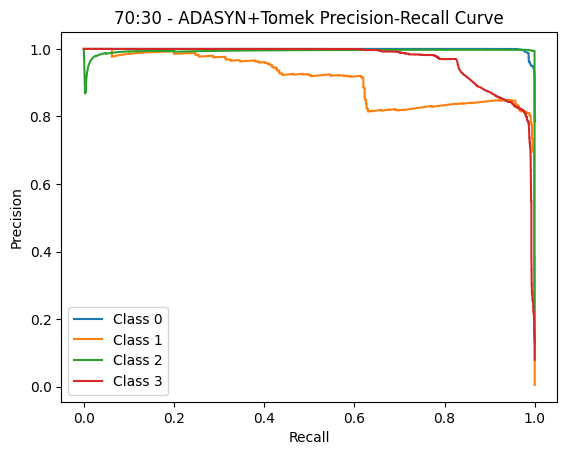

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    100755
           1       0.70      0.99      0.82       676
           2       1.00      1.00      1.00     16617
           3       0.76      0.99      0.86     10240

    accuracy                           0.97    128288
   macro avg       0.86      0.99      0.91    128288
weighted avg       0.98      0.97      0.97    128288

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 70:30: 3245.30 seconds
💾 RAM used for 70:30: 54.43 MB

===== Split 80:20 with ADASYN + TomekLinks =====
Original Training size: 342100 | Testing size: 85525
Training size after ADASYN + TomekLinks: 1068035


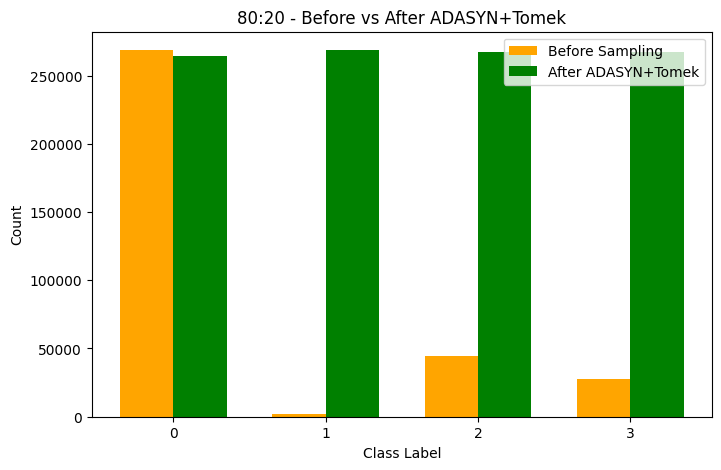

Epoch 1: TrainAcc=0.9214, TestAcc=0.9249, ROC=0.9829
Epoch 2: TrainAcc=0.9587, TestAcc=0.9240, ROC=0.9862
Epoch 3: TrainAcc=0.9622, TestAcc=0.9249, ROC=0.9867
Epoch 4: TrainAcc=0.9668, TestAcc=0.9265, ROC=0.9874
Epoch 5: TrainAcc=0.9684, TestAcc=0.9276, ROC=0.9874
Epoch 6: TrainAcc=0.9695, TestAcc=0.9265, ROC=0.9870
Epoch 7: TrainAcc=0.9703, TestAcc=0.9274, ROC=0.9873
Epoch 8: TrainAcc=0.9712, TestAcc=0.9275, ROC=0.9879
Epoch 9: TrainAcc=0.9719, TestAcc=0.9276, ROC=0.9879
Epoch 10: TrainAcc=0.9741, TestAcc=0.9541, ROC=0.9953
Epoch 11: TrainAcc=0.9844, TestAcc=0.9602, ROC=0.9960
Epoch 12: TrainAcc=0.9855, TestAcc=0.9719, ROC=0.9972
Epoch 13: TrainAcc=0.9862, TestAcc=0.9668, ROC=0.9965
Epoch 14: TrainAcc=0.9872, TestAcc=0.9730, ROC=0.9971
Epoch 15: TrainAcc=0.9874, TestAcc=0.9720, ROC=0.9971
Epoch 16: TrainAcc=0.9876, TestAcc=0.9705, ROC=0.9966
Epoch 17: TrainAcc=0.9879, TestAcc=0.9707, ROC=0.9967
Epoch 18: TrainAcc=0.9880, TestAcc=0.9708, ROC=0.9968
Epoch 19: TrainAcc=0.9880, TestAcc=0.

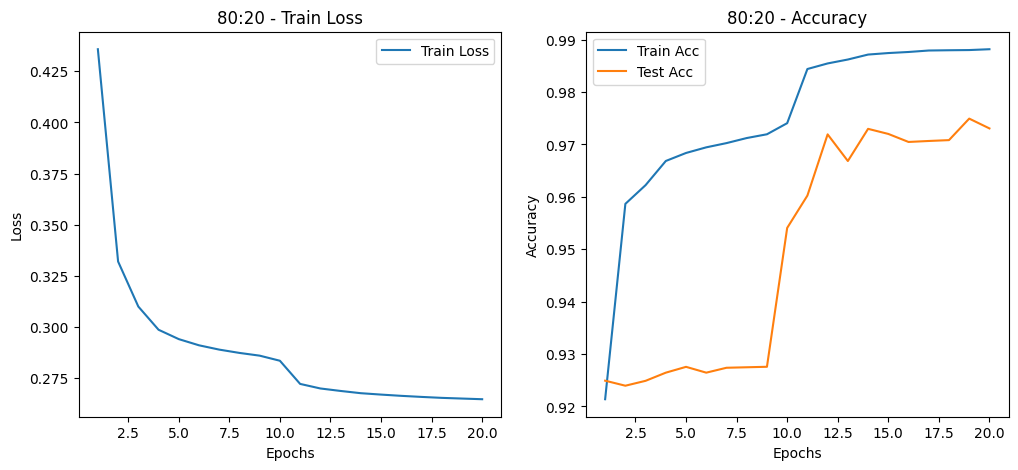

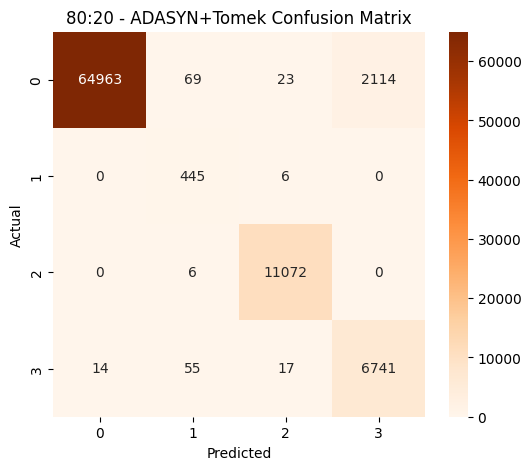

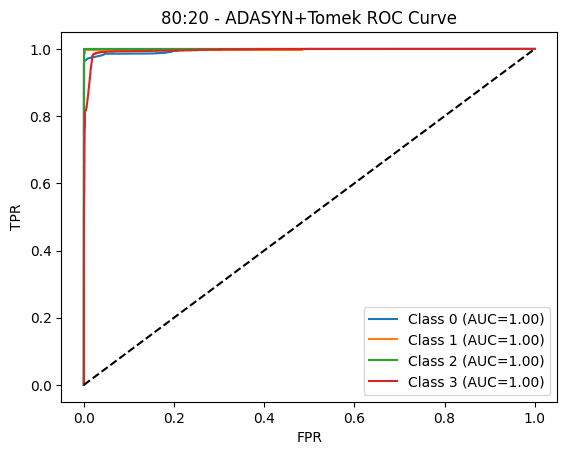

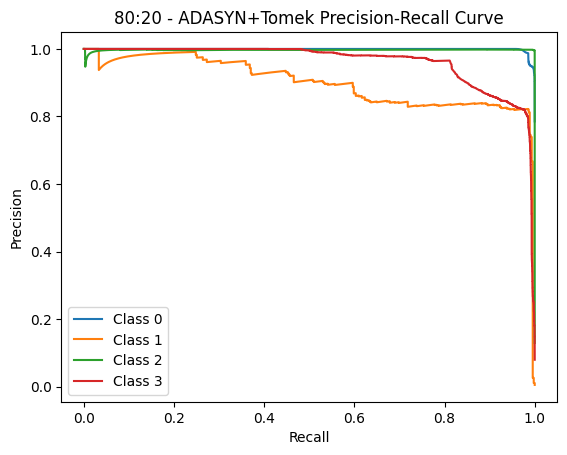

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     67169
           1       0.77      0.99      0.87       451
           2       1.00      1.00      1.00     11078
           3       0.76      0.99      0.86      6827

    accuracy                           0.97     85525
   macro avg       0.88      0.99      0.93     85525
weighted avg       0.98      0.97      0.97     85525

🚀 GPU Memory used: 26.83 MB

⏱️ Runtime for 80:20: 4022.45 seconds
💾 RAM used for 80:20: -4.68 MB


In [17]:
splits = {"60:40":0.4, "70:30":0.3, "80:20":0.2}

for split_name, test_size in splits.items():

    print(f"\n===== Split {split_name} with ADASYN + TomekLinks =====")

    # ⏱️ Start time
    start_time = time.time()

    # 💾 Start RAM
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)  # MB

    # Original dataset
    X = df.drop("label", axis=1).values
    y = df["label"].values

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print(f"Original Training size: {X_train.shape[0]} | Testing size: {X_test.shape[0]}")

    # 📊 BEFORE sampling
    unique_before, counts_before = np.unique(y_train, return_counts=True)

    # 🔥 ADASYN oversampling
    adasyn = ADASYN()
    X_train, y_train = adasyn.fit_resample(X_train, y_train)

    # 🔥 TomekLinks cleaning
    tl = TomekLinks()
    X_train, y_train = tl.fit_resample(X_train, y_train)

    print(f"Training size after ADASYN + TomekLinks: {X_train.shape[0]}")

    # 📊 AFTER sampling
    unique_after, counts_after = np.unique(y_train, return_counts=True)

    # 📊 Combined comparison plot
    labels = np.unique(np.concatenate((unique_before, unique_after)))

    before_dict = dict(zip(unique_before, counts_before))
    after_dict = dict(zip(unique_after, counts_after))

    before_vals = [before_dict.get(i, 0) for i in labels]
    after_vals = [after_dict.get(i, 0) for i in labels]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, before_vals, width, label='Before Sampling', color='orange')
    plt.bar(x + width/2, after_vals, width, label='After ADASYN+Tomek', color='green')

    plt.xticks(x, labels)
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.title(f"{split_name} - Before vs After ADASYN+Tomek")
    plt.legend()
    plt.show()

    # Scaling
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # DataLoaders
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test_scaled, y_test), batch_size=64)

    # Model
    model = HybridModel(X.shape[1], 64, len(np.unique(y))).to(device)

    # Class weights
    class_weights = torch.tensor(
        compute_class_weight('balanced', classes=np.unique(y_train), y=y_train),
        dtype=torch.float32
    ).to(device)

    criterion = torch.nn.NLLLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Training
    history = {"train_loss": [], "train_acc": [], "val_acc": [], "roc_auc": []}

    for epoch in range(20):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc, preds, true, probs = evaluate(model, test_loader)

        history["train_loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["roc_auc"].append(roc)

        print(f"Epoch {epoch+1}: TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC={roc:.4f}")

    # 📉 Loss + Accuracy curves
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(range(1,21), history["train_loss"], label="Train Loss")
    plt.title(f"{split_name} - Train Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(1,21), history["train_acc"], label="Train Acc")
    plt.plot(range(1,21), history["val_acc"], label="Test Acc")
    plt.title(f"{split_name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

    # 🔥 Confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(true, preds), annot=True, fmt="d", cmap="Oranges")
    plt.title(f"{split_name} - ADASYN+Tomek Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 📈 ROC Curve
    num_classes = len(np.unique(y))
    true_bin = label_binarize(true, classes=list(range(num_classes)))

    plt.figure()
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(true_bin[:,i], probs[:,i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr,tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{split_name} - ADASYN+Tomek ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

    # 📈 Precision-Recall Curve
    plt.figure()
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(true_bin[:,i], probs[:,i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.title(f"{split_name} - ADASYN+Tomek Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.show()

    # 📄 Classification report
    print(classification_report(true, preds))

    # ⏱️ End time
    end_time = time.time()
    total_time = end_time - start_time

    # 💾 End RAM
    end_ram = process.memory_info().rss / (1024 ** 2)
    ram_used = end_ram - start_ram

    # 🚀 Optional GPU memory
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
        print(f"🚀 GPU Memory used: {gpu_mem:.2f} MB")
        torch.cuda.reset_peak_memory_stats()

    # ✅ Final metrics
    print(f"\n⏱️ Runtime for {split_name}: {total_time:.2f} seconds")
    print(f"💾 RAM used for {split_name}: {ram_used:.2f} MB")

# Run the code before this only, after this code is not good

In [ ]:
def create_graph(num_features, k=5):
    edge_list = []
    for i in range(num_features):
        for j in range(i+1, min(i+k+1, num_features)):
            edge_list.append([i, j])
            edge_list.append([j, i])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

In [ ]:
class CNNBranch(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        return self.pool(x).squeeze(-1)


In [ ]:
class LSTMBranch(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.lstm = nn.LSTM(in_features, 64, batch_first=True)

    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h, _) = self.lstm(x)
        return h[-1]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GNNBranch(nn.Module):
    def __init__(self, node_feature_dim, num_features_in_graph):
        super().__init__()
        self.gcn1 = GCNConv(node_feature_dim, 64)
        self.gcn2 = GCNConv(64, 64)
        self.num_features_in_graph = num_features_in_graph

    def forward(self, x_batch, feature_edge_index): # x_batch: (batch_size, num_features)
        batch_size, num_features = x_batch.shape

        # Reshape x_batch to (batch_size * num_features, node_feature_dim)
        # where node_feature_dim is 1, as each feature value is a node's feature
        node_features = x_batch.view(-1, 1) # (batch_size * num_features, 1)

        # Create a batch tensor for torch_geometric's global_mean_pool
        # Each original sample's features form a separate graph for pooling
        batch_tensor = torch.arange(batch_size, device=x_batch.device).repeat_interleave(num_features)

        # Apply GCN layers
        x_gnn = F.relu(self.gcn1(node_features, feature_edge_index))
        x_gnn = F.relu(self.gcn2(x_gnn, feature_edge_index))

        # Global mean pool over the nodes of each graph in the batch
        # The output will be (batch_size, 64)
        return global_mean_pool(x_gnn, batch_tensor)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class HybridModel(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.cnn = CNNBranch(in_features)
        self.lstm = LSTMBranch(in_features)
        # GNNBranch now needs node_feature_dim (1) and num_features_in_graph (in_features)
        self.gnn = GNNBranch(1, in_features)

        self.fc1 = nn.Linear(64 * 3, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, feature_edge_index): # x is batch_size x num_features
        c = self.cnn(x)
        l = self.lstm(x)
        # Pass the input features (x) and the global feature graph structure
        g = self.gnn(x, feature_edge_index)
        fused = torch.cat([c, l, g], dim=1)
        fused = F.relu(self.fc1(fused))
        return self.fc2(fused)

In [ ]:
def run_experiment(name, train_path, test_path, epochs=20):
    print(f"\n========== Ratio {name} ==========")

    X_train, y_train = load_csv(train_path)
    X_test, y_test = load_csv(test_path)

    print(f"Unique labels in y_train before scaling: {np.unique(y_train)}")
    print(f"Unique labels in y_test before scaling: {np.unique(y_test)}")

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test  = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test  = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), batch_size=64
    )

    # Create the feature graph structure once
    feature_edge_index = create_graph(X_train.shape[1]).to(device)

    model = HybridModel(
        X_train.shape[1], # in_features is the number of features in input data
        len(torch.unique(y_train))
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_losses = []

    # ======================z
    # TRAINING and EVALUATION loop
    # ======================
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        # Training loop with tqdm
        train_progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} (Train)")
        for x, y in train_progress_bar:
            optimizer.zero_grad()
            out = model(x.to(device), feature_edge_index)
            loss = criterion(out, y.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            train_progress_bar.set_postfix_str(f"Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Avg Loss: {avg_loss:.4f}")

        # ======================
        # TESTING (per epoch)
        # ======================
        model.eval()
        y_true_epoch, y_pred_epoch, y_prob_epoch = [], [], []

        with torch.no_grad():
            test_progress_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} (Test)")
            for x, y in test_progress_bar:
                out = model(x.to(device), feature_edge_index)
                prob = F.softmax(out, dim=1)

                y_true_epoch.extend(y.numpy())
                y_pred_epoch.extend(out.argmax(1).cpu().numpy())
                y_prob_epoch.extend(prob[:, 1].cpu().numpy())

        acc_epoch = accuracy_score(y_true_epoch, y_pred_epoch)

        # Robust ROC-AUC calculation
        unique_classes_epoch = np.unique(y_true_epoch)
        if len(unique_classes_epoch) < 2:
            roc_auc_epoch = float('nan') # Cannot calculate ROC-AUC with less than 2 classes
            print(f"Warning: ROC-AUC not calculated for Epoch {epoch+1} due to insufficient classes in y_true_epoch ({len(unique_classes_epoch)} classes found).")
        elif len(unique_classes_epoch) == 2:
            roc_auc_epoch = roc_auc_score(y_true_epoch, y_prob_epoch)
        else:
            # If there are unexpectedly more than 2 classes, treat as multi-class OVR
            # This implies prob[:, 1] might be problematic if not a binary problem
            # but aligns with the error message's suggestion for multi_class.
            # For robustness, we assume the model output 'out' has scores for all classes
            # and y_prob_epoch should be the full probability matrix in this case.
            # However, since the current code only captures prob[:, 1], we adjust if it's truly multi-class.
            # Let's adjust y_prob_epoch to be 2D if num_classes > 2 and y_prob_epoch is 1D.
            # If it's a true multi-class problem, y_prob_epoch should have been `prob.cpu().numpy()`
            # If the user intends binary, this is an issue with y_true.
            # For now, let's proceed with ovr and assume y_prob_epoch is for class 1 vs rest if num_classes > 2
            # To correctly calculate ROC-AUC for multi-class, y_prob_epoch would need to be 2D (n_samples, n_classes).
            # Given prob[:, 1] is extracted, this is a strong indicator of binary intent.
            # The error 'multi_class must be in ('ovo', 'ovr')' happens when y_true has >2 classes.
            # For a binary ROC-AUC, if y_true has >2 classes, the data is malformed for this metric.
            # Let's log a warning and default to NaN or raise a more specific error.
            roc_auc_epoch = float('nan')
            print(f"Warning: ROC-AUC not calculated for Epoch {epoch+1}. Detected {len(unique_classes_epoch)} classes in y_true_epoch, but y_prob_epoch is 1D. This suggests a mismatch between data labels and evaluation strategy for ROC-AUC.")

        cm_epoch = confusion_matrix(y_true_epoch, y_pred_epoch)
        report_epoch = classification_report(y_true_epoch, y_pred_epoch, output_dict=True)

        print(f"Epoch [{epoch+1}/{epochs}] Accuracy: {acc_epoch:.4f}, ROC-AUC: {roc_auc_epoch:.4f}")
        print(f"Epoch [{epoch+1}/{epochs}] Classification Report:\n{classification_report(y_true_epoch, y_pred_epoch)}")

    # ======================
    # FINAL EVALUATION (after all epochs, for plotting)
    # ======================
    model.eval()
    y_true_final, y_pred_final, y_prob_final = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device), feature_edge_index)
            prob = F.softmax(out, dim=1)

            y_true_final.extend(y.numpy())
            y_pred_final.extend(out.argmax(1).cpu().numpy())
            y_prob_final.extend(prob[:, 1].cpu().numpy())

    acc_final = accuracy_score(y_true_final, y_pred_final)

    unique_classes_final = np.unique(y_true_final)
    if len(unique_classes_final) < 2:
        roc_auc_final = float('nan')
        print(f"Warning: Final ROC-AUC not calculated due to insufficient classes in y_true_final ({len(unique_classes_final)} classes found).")
    elif len(unique_classes_final) == 2:
        roc_auc_final = roc_auc_score(y_true_final, y_prob_final)
    else:
        roc_auc_final = float('nan')
        print(f"Warning: Final ROC-AUC not calculated. Detected {len(unique_classes_final)} classes in y_true_final, but y_prob_final is 1D. This suggests a mismatch between data labels and evaluation strategy for ROC-AUC.")

    cm_final = confusion_matrix(y_true_final, y_pred_final)

    # ======================
    # ⛰️ GRAPHS
    # ======================

    # 1‼️ Training Loss Curve
    plt.figure()
    plt.plot(train_losses)
    plt.title(f"Training Loss – Ratio {name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    # 2‼️ ROC Curve
    fpr, tpr, _ = roc_curve(y_true_final, y_prob_final) # This will fail if roc_auc_final is NaN, or if y_prob_final is not 1D
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_final:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – Ratio {name}")
    plt.legend()
    plt.show()

    # 3‼️ Confusion Matrix Heatmap
    plt.figure()
    sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – Ratio {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 4‼️ Precision–Recall Curve (BONUS)
    precision, recall, _ = precision_recall_curve(y_true_final, y_prob_final) # This will fail if y_prob_final is not 1D
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – Ratio {name}")
    plt.legend()
    plt.show()

    return {
        "loss": train_losses,
        "accuracy": acc_final,
        "roc_auc": roc_auc_final,
        "confusion_matrix": cm_final
    }

In [ ]:
results = {}

for ratio, paths in datasets.items():
    results[ratio] = run_experiment(
        ratio,
        paths["train"],
        paths["test"]
    )